In [1]:
import pandas as pd
import numpy as np

np.random.seed(42) #결과 재현용
n = 200
df = pd.DataFrame({
    'time':pd.date_range('2026-03-01',periods=n, freq ='s'),
    'temp':np.random.normal(450,5,n), #온도 ~450도
    'pressure':np.random.normal(1.0,0.05,n), # 압력 ~1.0Pa
    'vibration':np.random.normal(0.3,0.1,n) #진동 ~0.3mm/s

})
df
print(df.shape)
df

(200, 4)


,time,temp,pressure,vibration
0,2026-03-01 00:00:00,452.483571,1.017889,0.140557
1,2026-03-01 00:00:01,449.308678,1.028039,0.240062
2,2026-03-01 00:00:02,453.238443,1.054153,0.300524
3,2026-03-01 00:00:03,457.615149,1.052690,0.304698
4,2026-03-01 00:00:04,448.829233,0.931117,0.254993
...,...,...,...,...
195,2026-03-01 00:03:15,451.926587,0.976541,0.248998
196,2026-03-01 00:03:16,445.580713,0.914343,0.273013
197,2026-03-01 00:03:17,450.768626,1.067694,0.202124
198,2026-03-01 00:03:18,450.291044,0.994273,0.255571


In [2]:
# 1) 결측치 : 30개를 무작위로 NaN 처리
idx = np.random.choice(df.index, 30, replace =False)
df.loc[idx,'temp'] = np.nan
df

# 2)이상치 : 5개를 비정상 고온으로
df.loc[df.index[:5], 'temp'] = 9999
df

# 3) 중복 : 앞 3행을 통째로 복제해 추가
df = pd.concat([df, df.iloc[:3]], ignore_index=True)
df

# 자료형 오류 : 압력을 문자열로
df['pressure'] = df['pressure'].astype(str)
df.to_csv('messy.csv',index = False) #저장

# 더러운 데이터 다시 읽기
df = pd.read_csv('messy.csv')

print(df.info()) #자료형 결측 개수 한눈에
print(df.isnull().sum())# 컬럼별 결측치 개수
print(df.duplicated().sum()) # 중복행 개수 
print(df.describe()) #통계요약 (이상치힌트)

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       203 non-null    str    
 1   temp       174 non-null    float64
 2   pressure   203 non-null    float64
 3   vibration  203 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.5 KB
None
time          0
temp         29
pressure      0
vibration     0
dtype: int64
3
              temp    pressure   vibration
count   174.000000  203.000000  203.000000
mean    888.917376    1.004723    0.290483
std    2005.700126    0.049144    0.099296
min     436.901274    0.837937    0.052836
25%     446.475030    0.970010    0.220512
50%     450.340228    1.004850    0.291088
75%     453.742832    1.034410    0.356678
max    9999.000000    1.192637    0.607888


In [3]:
# 결측이 있는 행 저전체 삭제 
df_drop = df.dropna()
print(len(df)), '→',len(df_drop) #203 > 173

#특정컬럼기준으로 만 삭제
df2 = df.dropna(subset=['temp'])

#결측이 너무 많은 '열' 삭제(예 50이상)
df3 = df.dropna(axis=1, thresh=len(df) * 0.5)

# 평균값으로 채우기 
df_mean = df.copy()
df_mean['temp'] = df_mean['temp'].fillna(df_mean['temp'].mean())

# 중앙값으로 채우기
df_median = df.copy()
df_median['temp'] = df_median['temp'].fillna(df_median['temp'].median())

# 직전 값으로 채우기
df_ffill = df.copy()
df_ffill['temp'] = df_ffill['temp'].ffill()

203


In [4]:
print("원본 결측치 개수")
print(df['temp'].isnull().sum())

print("평균 대체 후 결측치 개수")
print(df_mean['temp'].isnull().sum())

print("중앙값 대체 후 결측치 개수")
print(df_median['temp'].isnull().sum())

print("ffill 대체 후 결측치 개수")
print(df_ffill['temp'].isnull().sum())

원본 결측치 개수
29
평균 대체 후 결측치 개수
0
중앙값 대체 후 결측치 개수
0
ffill 대체 후 결측치 개수
0


In [5]:
# temp 컬럼에서 결측치는 잠시 제외하고 IQR 계산

temp_data = df['temp'].dropna() #결측치 제외한 temp 데이터
Q1 = temp_data.quantile(0.25)
Q3 = temp_data.quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR
print("IQR:", IQR)
print("정상범위:", low, "~", high)
#정상 범위 안의 값만 남기기
mask = (df['temp'] >= low) & (df['temp'] <= high)
df_clean = df[mask]
print("원본 행 개수: ", len(df))
print("IQR 이상치 제거 후 행 개수: ", len(df_clean))
print("이상치 제거 후 temp 최대값:", df_clean['temp'].max())

IQR: 7.267802415550989
정상범위: 435.57332605869215 ~ 464.6445357208961
원본 행 개수:  203
IQR 이상치 제거 후 행 개수:  166
이상치 제거 후 temp 최대값: 463.6008458329481


In [6]:

#실습 4-2 Z score 이상치 탐지
# Z-score= (값 - 평균) / 표준편차 → 평균에서 몇 표준편차 떨어져 있는지

# [실습 4-2] Z score 이상치 탐지
temp_data = df['temp'].dropna() #결측치 제외한 temp 데이터
mean = temp_data.mean()
std = temp_data.std()
df_z = df.copy()
df_z['z'] = (df_z['temp'] - mean) / std
df_z_clean = df_z[df_z['z'].abs() <= 3]
df_z_clean = df_z_clean.drop(columns='z')
print("Z-score 기준 이상치 제거 후 행 개수: ", len(df_z_clean))
print("Z-score 기준 제거 후 temp 최대값:", df_z_clean['temp'].max())


Z-score 기준 이상치 제거 후 행 개수:  166
Z-score 기준 제거 후 temp 최대값: 463.6008458329481


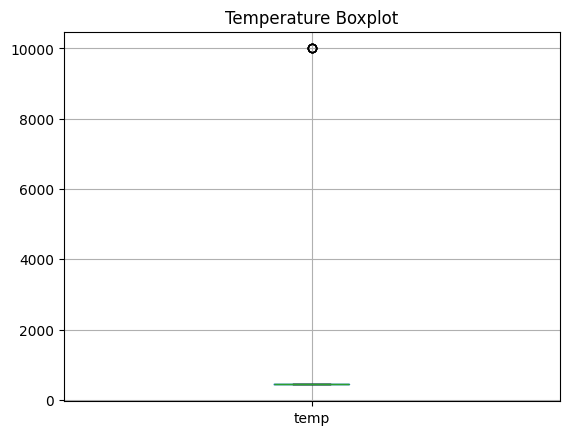

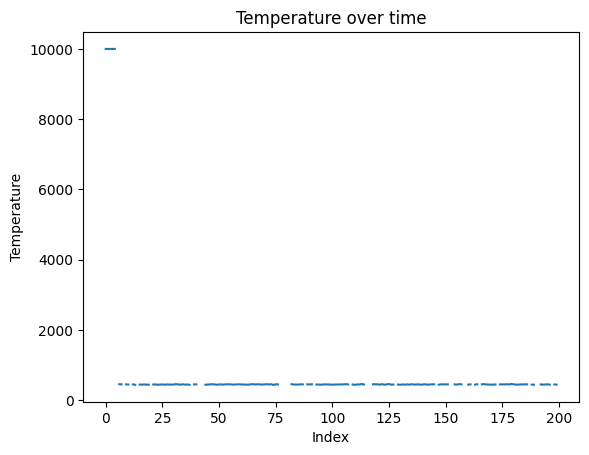

<function matplotlib.pyplot.show(close=None, block=None)>

In [54]:

# [실습 4-3] 시각화로 눈으로 확인하기
# 숫자만으로 감이 안옵니다. 그래프로 그리면 이상치가 한누에 보입니다.





import matplotlib.pyplot as plt
#[실습 4-3] 시각화로 이상치 확인
import matplotlib.pyplot as plt
#박스플롯: 이상치가 점으로 튀어나옴

df.boxplot(column='temp')
plt.title('Temperature Boxplot')
plt.show()

#시계열 선그래프 : 9999 지점이 위로 솟구침
df['temp'].plot(title = 'Temperature over time')
plt.xlabel('Index')
plt.ylabel('Temperature')
plt.show()

# 이상치 제거 후 다시 확인
df_clean['temp'].plot(title = 'Temperature after IQR Claeaning')
plt.xlabel('Index')
plt.ylabel('Temperature')
plt.show

In [68]:
# 1) 중복 행 제거
print(df.duplicated().sum()) # 3
df = df.drop_duplicates()
# 2) 문자열 → 숫자 변환
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')
# 3) 문자열 → 날짜시간 변환
df['time'] = pd.to_datetime(df['time'])
print(df.dtypes) # 타입 확인

0
time         datetime64[us]
temp                float64
pressure            float64
vibration           float64
dtype: object


In [56]:
# [실습 6-1] 정규화 & 표준화
# 기준 데이터 선택 : 이상치 제거 데이터 사용
df_scale = df_clean.copy()
#결측치가 남아 있으면 중앙값으로 대체
df_scale['temp'] = df_scale['temp'].fillna(df_scale['temp'].median())
#방법 A) Min - max 정규화
c = df_scale['temp']
df_scale['temp_minmax'] = (c - c.min()) / (c.max() - c.min())

#방법 B) StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['temp', 'pressure', 'vibration']    

df_scale[cols] = scaler.fit_transform(df_scale[cols])
print(df_scale[cols].describe())

               temp      pressure     vibration
count  1.910000e+02  1.910000e+02  1.910000e+02
mean  -1.444917e-14  3.180702e-15 -3.394609e-16
std    1.002628e+00  1.002628e+00  1.002628e+00
min   -2.385994e+00 -3.384559e+00 -2.428518e+00
25%   -6.542850e-01 -6.985434e-01 -7.113260e-01
50%    1.207682e-01 -1.704959e-02  1.058746e-02
75%    5.035484e-01  6.005020e-01  6.591639e-01
max    2.400002e+00  3.817307e+00  3.199398e+00


In [65]:
def clean_pipeline(path):
    df = pd.read_csv(path)
# 1) 자료형
    df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')
    df['time'] = pd.to_datetime(df['time'])
# 2) 중복 / 3) 이상치(IQR)
    df = df.drop_duplicates()
    Q1, Q3 = df['temp'].quantile([.25, .75])
    iqr = Q3 - Q1
    df = df[(df['temp'] >= Q1-1.5*iqr) & (df['temp'] <= Q3+1.5*iqr)]
# 4) 결측 대체 / 5) 표준화
    df['temp'] = df['temp'].fillna(df['temp'].median())
    df.to_csv('clean.csv', index=False)
    return df

In [66]:
df = clean_pipeline('messy.csv')
# 검증: 모든 문제가 사라졌는지 확인
print(df.isnull().sum().sum()) # 0 (결측 없음)
print(df.duplicated().sum()) # 0 (중복 없음)
print(df['temp'].max()) # 9999 사라짐
print(df.dtypes) # 타입 정상

0
0
463.6008458329481
time         datetime64[us]
temp                float64
pressure            float64
vibration           float64
dtype: object
